In [158]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# mpl.rc('font', family='serif', serif='cmr10', size=10)
mpl.rc('font', family='times new roman', size=12)
plt.rcParams['axes.unicode_minus'] = False

In [159]:
import pandas as pd
df0 = pd.read_csv('p_grid_results_price_20.csv',sep=',')
df0

,h,s,p_grid,omega,p_wt,p_el,p_comp,m_in,m_out,m_tank
0,1,1,643.359068,1036.9096,829.405786,1440.716970,32.047885,28871.96808,25000.00000,3871.968077
1,1,2,600.146260,1250.2617,963.377697,1529.501122,34.022835,30651.20249,25000.00000,5651.202488
2,1,3,0.000000,96.7304,531.543523,519.976948,11.566575,10420.33804,10420.33804,0.000000
3,2,1,359.126855,709.8295,720.603448,1056.234989,23.495314,21166.94919,25000.00000,38.917262
4,2,2,618.916093,749.2752,855.516985,1442.348891,32.084186,28904.67179,25000.00000,9555.874273
...,...,...,...,...,...,...,...,...,...,...
499,167,2,419.257082,988.0428,855.997908,1247.504990,27.750000,25000.00000,25000.00000,0.000000
500,167,3,0.000000,0.0000,586.147956,573.393169,12.754787,11490.79911,11490.79911,0.000000
501,168,1,337.740352,477.7642,937.514638,1247.504990,27.750000,25000.00000,25000.00000,0.000000
502,168,2,412.463575,1062.7963,862.791415,1247.504990,27.750000,25000.00000,25000.00000,0.000000


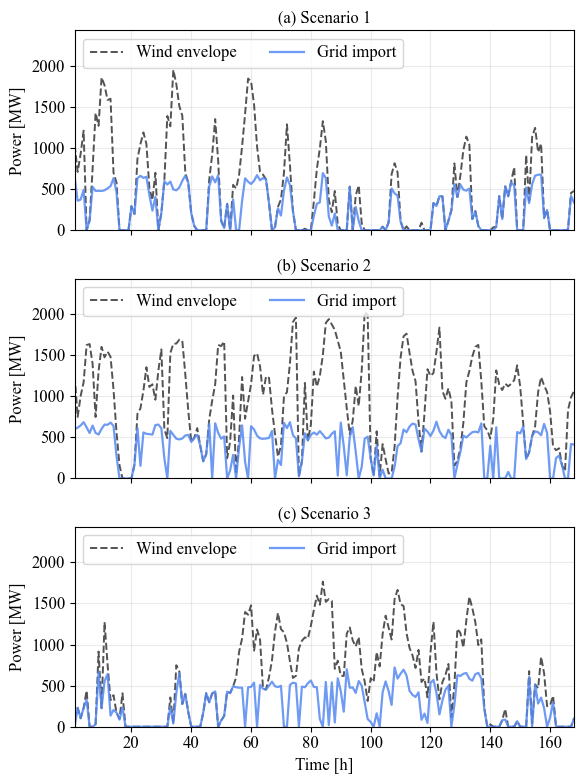

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure numeric
df0["h"] = pd.to_numeric(df0["h"], errors="raise")
df0["s"] = pd.to_numeric(df0["s"], errors="raise")
df0["p_grid"] = pd.to_numeric(df0["p_grid"], errors="raise")
df0["omega"] = pd.to_numeric(df0["omega"], errors="raise")

scenarios = sorted(df0["s"].unique())
if len(scenarios) != 3:
    print(f"Warning: expected 3 scenarios, found {len(scenarios)} -> {scenarios}")

# Common y-limits for fair comparison
ymax = np.nanmax([df0["p_grid"].max(), df0["omega"].max()])
ymin = 0.0

fig, axes = plt.subplots(
    nrows=len(scenarios), ncols=1,
    figsize=(6, 8.0),
    sharex=True, sharey=True
)

if len(scenarios) == 1:
    axes = [axes]

for idx, (ax, s) in enumerate(zip(axes, scenarios)):
    d = df0[df0["s"] == s].sort_values("h")

    ax.plot(d["h"], d["omega"], linestyle="--", linewidth=1.4, label="Wind envelope", color="#363535", alpha = 0.85)
    ax.plot(d["h"], d["p_grid"], linestyle="-",  linewidth=1.6, label="Grid import", color="#5589F2", alpha = 0.85)


    ax.set_ylim(ymin, ymax*1.2)
    ax.set_xlim(d["h"].min(), d["h"].max())
    ax.set_ylabel("Power [MW]")
    ax.grid(True, axis="both", alpha=0.25)
    ax.legend(loc="upper left", fontsize=12, ncols=2)
    panel = chr(ord("a") + idx)
    ax.set_title(f"({panel}) Scenario {int(s)}", loc="center", fontsize=12)

axes[-1].set_xlabel("Time [h]")

plt.tight_layout()
plt.savefig("grid_power_comparison.pdf", bbox_inches="tight")
plt.show()


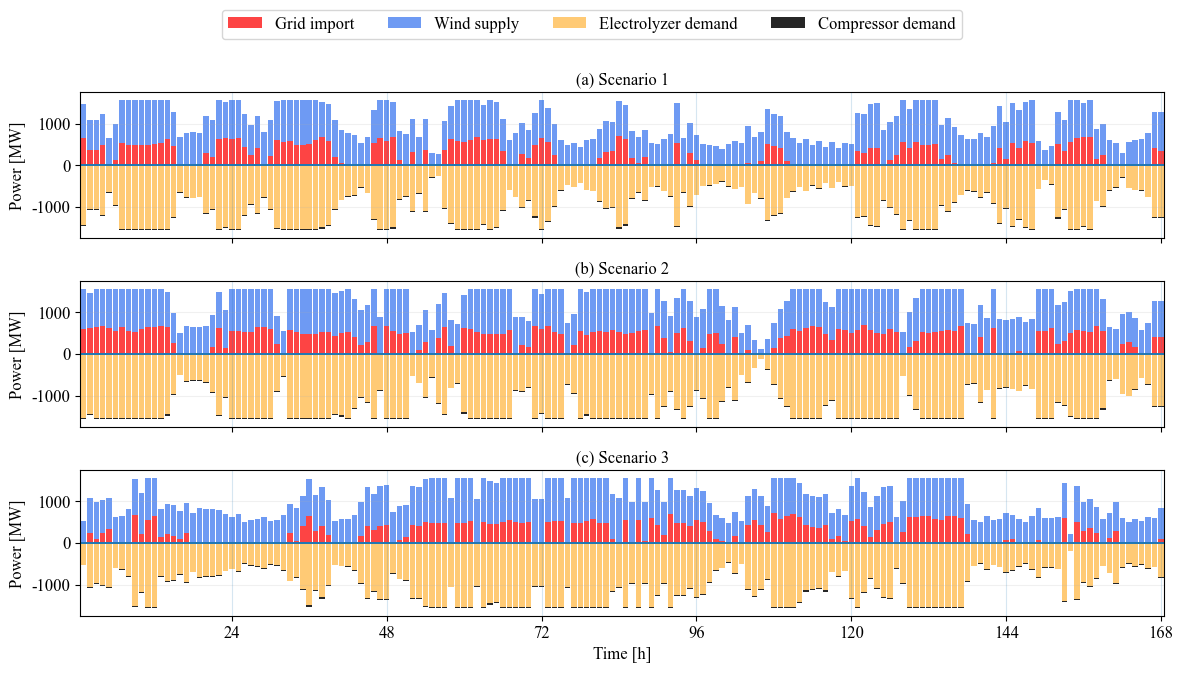

In [161]:
import numpy as np
import matplotlib.pyplot as plt

# --- assumes df0 has columns: h, s, p_grid, p_wt, p_el, p_comp ---
scenarios = sorted(df0["s"].unique())

fig, axes = plt.subplots(
    nrows=len(scenarios), ncols=1,
    figsize=(12, 6.6),
    sharex=True, sharey=True
)

if len(scenarios) == 1:
    axes = [axes]

# Consistent styling
BAR_W = 0.85
ALPHA = 0.85
DAY = 24

for idx, (ax, s) in enumerate(zip(axes, scenarios)):
    d = df0[df0["s"] == s].sort_values("h").copy()

    h = d["h"].to_numpy()

    # Supply (positive)
    grid = d["p_grid"].to_numpy()
    wind = d["p_wt"].to_numpy()

    # Demand (plotted negative for readability)
    el_neg = -d["p_el"].to_numpy()
    comp_neg = -d["p_comp"].to_numpy()

    # ---- Positive stack: Grid + Wind ----
    ax.bar(h, grid, width=BAR_W, label="Grid import", alpha=ALPHA, color="#FD2323")
    ax.bar(h, wind, width=BAR_W, bottom=grid, label="Wind supply", alpha=ALPHA, color="#5589F2")

    # ---- Negative stack: Electrolyzer + Compressor ----
    ax.bar(h, el_neg, width=BAR_W, label="Electrolyzer demand", alpha=ALPHA, color="#FFC15D")
    ax.bar(h, comp_neg, width=BAR_W, bottom=el_neg, label="Compressor demand", alpha=ALPHA, color="#000000")

    # Emphasize the zero line
    ax.axhline(0, linewidth=1.4)

    # Day separators (every 24 h)
    hmin = int(np.floor(h.min()))
    hmax = int(np.ceil(h.max()))
    day_marks = np.arange((hmin // DAY + 1) * DAY, hmax + 1, DAY)
    for dm in day_marks:
        ax.axvline(dm, linewidth=0.8, alpha=0.18)

    # Cosmetics
    ax.set_ylabel("Power [MW]")
    ax.grid(True, axis="y", alpha=0.18)
    ax.grid(False, axis="x")
    panel = chr(ord("a") + idx)
    ax.set_title(f"({panel}) Scenario {int(s)}", fontsize=12)

# Shared legend (single)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 1.03)
)

# X ticks every 24 h
xmin = df0["h"].min()
xmax = df0["h"].max()
xticks = np.arange(int(np.floor(xmin / DAY)) * DAY, int(np.ceil(xmax / DAY)) * DAY + 1, DAY)
axes[-1].set_xticks(xticks)
axes[-1].set_xlabel("Time [h]")
axes[-1].set_xlim(xmin - 0.5, xmax + 0.5)

# Shared y-lims (keeps comparability)
pos_max = (df0["p_grid"] + df0["p_wt"]).max()
neg_min = -(df0["p_el"] + df0["p_comp"]).max()
ymax = np.ceil(pos_max / 250) * 250
ymin = -np.ceil(abs(neg_min) / 250) * 250
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("power_supply_demand_stack.pdf", bbox_inches="tight")
plt.show()


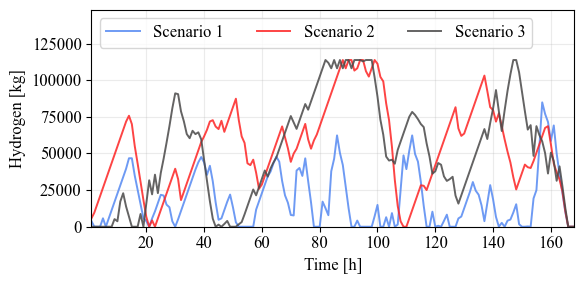

In [166]:
# Common y-limits for fair comparison
ymax = df0["m_tank"].max()
ymin = 0.0

# Set specific colors per curve
curve_colors = {
    "Scenario 1": "#5589F2",  # blue
    "Scenario 2": "#FD2323",  # orange
    "Scenario 3": "#494848",  # green
}

fig, ax = plt.subplots(figsize=(6, 3))

for s in scenarios:
    d = df0[df0["s"] == s].sort_values("h")
    label = f"Scenario {int(s)}"
    color = curve_colors.get(label, None)
    ax.plot(d["h"], d["m_tank"], linestyle="-", linewidth=1.4,
            label=label, color=color, alpha=0.85)

ax.set_xlim(df0["h"].min(), df0["h"].max())
ax.set_ylim(ymin, ymax * 1.3)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Hydrogen [kg]")
ax.grid(True, axis="both", alpha=0.25)
ax.legend(ncol=3, loc="upper left")

plt.tight_layout()
plt.savefig("hydrogen_tank_all_scenarios.pdf", bbox_inches="tight")
plt.show()


In [163]:
import pandas as pd
df1 = pd.read_csv('wind_profiles.csv',sep=',')
df1

,h,Scenario 1,Scenario 2,Scenario 3
0,1,0.858473,0.900416,0.912490
1,2,0.869290,0.801976,0.738599
2,3,0.960896,0.906306,0.660693
3,4,0.993691,0.961616,0.734159
4,5,0.785778,0.984375,0.813699
...,...,...,...,...
163,164,0.401486,0.717599,0.689430
164,165,0.506182,0.734029,0.572504
165,166,0.372308,0.878156,0.603768
166,167,0.480332,0.910871,0.582398


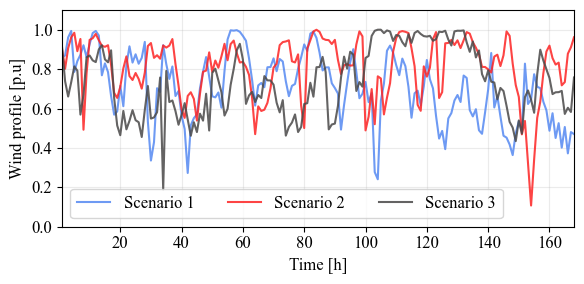

In [167]:
# Detect a likely time column (if present)
hour_candidates = [c for c in df1.columns if str(c).strip().lower() in ("h", "hour", "hours", "time")]
hour_col = hour_candidates[0] if hour_candidates else None

# Build x-axis from time column, otherwise use row index
x = pd.to_numeric(df1[hour_col], errors="coerce") if hour_col else pd.Series(range(len(df1)), index=df1.index)

# Set specific colors per curve
curve_colors = {
    "Scenario 1": "#5589F2",  # blue
    "Scenario 2": "#FD2323",  # orange
    "Scenario 3": "#494848",  # green
}

fig = plt.figure(figsize=(6, 3))
for c in df1.columns:
    if c == hour_col:
        continue
    y = pd.to_numeric(df1[c], errors="coerce")
    plt.plot(x, y, label=c, color=curve_colors.get(c, "#333333"), alpha=0.85)

plt.xlabel("Time [h]" if hour_col else "Index")
plt.ylabel("Wind profile [p.u]")
plt.xlim(x.min(), x.max())
plt.ylim(0, 1.1)
plt.legend(ncol=3, loc="lower left")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("wind_profiles.pdf", bbox_inches="tight")
plt.show()